# SFUMATO vs Xenium

This notebook compares SFUMATO transcript-level assignments with Xenium cell clusters.

It produces two heatmaps:
1. all SFUMATO assignments, without probability filtering;
2. high-confidence SFUMATO assignments, using `p1 >= P1_THRESHOLD`.

If `p1` is not present in `adata.obs`, it is reconstructed as `p1 = 1 - compl_p1`.


In [1]:
from pathlib import Path
import json
import warnings

from matplotlib.colors import LinearSegmentedColormap, Normalize, to_hex, to_rgb
from matplotlib.cm import ScalarMappable

import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex, to_rgb

try:
    from scipy.cluster import hierarchy
except Exception:
    hierarchy = None

sns.set_theme(style="white", context="paper")
pd.set_option("display.max_columns", 80)


c:\Users\alegi784\AppData\Local\anaconda3\envs\gene_analysis\Lib\site-packages\scanpy\_utils\__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
c:\Users\alegi784\AppData\Local\anaconda3\envs\gene_analysis\Lib\site-packages\scanpy\__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
c:\Users\alegi784\AppData\Local\anaconda3\envs\gene_analysis\Lib\site-packages\scanpy\readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
# -------------------------
# Parameters
# -------------------------
SFUMATO_H5AD = r"full\newcolors\mousexeniumcell_BGM68to45_BIN7_F5_SVD10_FULL.h5ad"
XENIUM_TRANSCRIPTS_PARQUET = r"Xenium_V1_FF_Mouse_Brain_Coronal_outs\transcripts.parquet"
XENIUM_CLUSTERS_CSV = r"Xenium_V1_FF_Mouse_Brain_Coronal_outs\analysis\clustering\gene_expression_graphclust\clusters.csv"

OUTPUT_DIR = "sfumato_xenium_comparison_BIN7"
PIXEL_SIZE = 0.2125
P1_THRESHOLD = 0.8
NORMALIZATION = "row"  # "row", "column", or "none"

# SFUMATO columns in adata.obs
SFUMATO_X_COL = "x"
SFUMATO_Y_COL = "y"
SFUMATO_GENE_COL = "target_name"
SFUMATO_CLUSTER_COL = "cluster"
SFUMATO_COLOR_COL = "color_hard"
SFUMATO_P1_COL = "p1"
SFUMATO_COMPL_P1_COL = "compl_p1"

# Xenium columns
XENIUM_CELL_ID_COL = "cell_id"
XENIUM_GENE_COL = "feature_name"
XENIUM_X_COL = "x_location"
XENIUM_Y_COL = "y_location"
XENIUM_CLUSTER_BARCODE_COL = "Barcode"
XENIUM_CLUSTER_COL = "Cluster"

SFUMATO_AREA_JSON = Path(
    r"full\cluster_masks_K45_BIN7_cell_level_SVD10_binlevel_low010_high030\cluster_areas_um2.json"
)

SFUMATO_FRACTION_JSON = SFUMATO_AREA_JSON.with_name("sfumato_area_fraction.json")

with open(SFUMATO_AREA_JSON, "r") as f:
    area_data = json.load(f)

areas = {
    cid.replace("p", ""): float(info["area_um2"])
    for cid, info in area_data["clusters"].items()
}

total_area = sum(areas.values())

sfumato_fraction = {
    cid: area / total_area
    for cid, area in areas.items()
}

with open(SFUMATO_FRACTION_JSON, "w") as f:
    json.dump(sfumato_fraction, f, indent=2)

print("Saved:", SFUMATO_FRACTION_JSON)
print("Total fraction:", sum(sfumato_fraction.values()))
print("First keys:", list(sfumato_fraction.keys())[:5])

XENIUM_CELL_COUNT_JSON = ""


Saved: full\cluster_masks_K45_BIN7_cell_level_SVD10_binlevel_low010_high030\sfumato_area_fraction.json
Total fraction: 1.0
First keys: ['1', '2', '3', '4', '5']


In [3]:
def read_table(path, **kwargs):
    path = Path(path)
    suffix = path.suffix.lower()
    if suffix == ".parquet":
        return pd.read_parquet(path, **kwargs)
    if suffix in {".csv", ".txt"}:
        return pd.read_csv(path, **kwargs)
    if suffix in {".tsv", ".tab"}:
        return pd.read_csv(path, sep="\t", **kwargs)
    raise ValueError(f"Unsupported table format: {path}")


def decode_if_bytes(series):
    return series.map(lambda x: x.decode("utf-8") if isinstance(x, (bytes, bytearray)) else x)


def add_confidence(obs, p1_col="p1", compl_p1_col="compl_p1"):
    obs = obs.copy()
    if p1_col in obs.columns:
        obs["p1"] = pd.to_numeric(obs[p1_col], errors="coerce")
    elif compl_p1_col in obs.columns:
        obs["p1"] = 1 - pd.to_numeric(obs[compl_p1_col], errors="coerce")
    else:
        warnings.warn(
            f"Neither {p1_col!r} nor {compl_p1_col!r} found. "
            "The high-confidence subset will be unavailable."
        )
        obs["p1"] = np.nan
    return obs


def add_integer_coordinates(df, x_col, y_col, x_out="x_int", y_out="y_int", scale=1.0, method="astype_int"):
    df = df.copy()
    x = pd.to_numeric(df[x_col], errors="coerce") / scale
    y = pd.to_numeric(df[y_col], errors="coerce") / scale
    if method == "round":
        df[x_out] = np.rint(x).astype("Int64")
        df[y_out] = np.rint(y).astype("Int64")
    elif method == "floor":
        df[x_out] = np.floor(x).astype("Int64")
        df[y_out] = np.floor(y).astype("Int64")
    elif method == "astype_int":
        df[x_out] = np.trunc(x).astype("Int64")
        df[y_out] = np.trunc(y).astype("Int64")
    else:
        raise ValueError("method must be one of: 'astype_int', 'round', 'floor'")
    return df


def clean_cluster_labels(series, drop_values=("-1", "nan", "None")):
    labels = series.astype("string")
    labels = labels.where(~labels.isna(), other=pd.NA)
    labels = labels.str.replace(r"\.0$", "", regex=True)
    return labels.where(~labels.isin(drop_values), other=pd.NA)


def load_json_mapping(path):
    if path is None or str(path).strip() == "":
        return None
    with open(path, "r") as f:
        data = json.load(f)
    return {str(k): float(v) for k, v in data.items()}


def grayscale_map(values, low=0.92, high=0.20):
    values = pd.Series(values, dtype="float64")
    finite = values.replace([np.inf, -np.inf], np.nan).dropna()
    if finite.empty:
        scaled = pd.Series(0.5, index=values.index)
    elif finite.max() == finite.min():
        scaled = pd.Series(0.5, index=values.index)
    else:
        scaled = (values - finite.min()) / (finite.max() - finite.min())
    scaled = scaled.fillna(0.0).clip(0, 1)
    gray = low + (high - low) * scaled
    return gray.map(lambda g: to_hex((g, g, g)))

def grayscale_cmap(low=0.92, high=0.20):
    return LinearSegmentedColormap.from_list(
        "annotation_gray",
        [(low, low, low), (high, high, high)]
    )


def numeric_norm(values):
    values = pd.Series(values, dtype="float64").replace([np.inf, -np.inf], np.nan)
    finite = values.dropna()

    if finite.empty:
        return Normalize(vmin=0, vmax=1)

    if finite.min() == finite.max():
        delta = abs(finite.min()) * 0.05 if finite.min() != 0 else 1
        return Normalize(vmin=finite.min() - delta, vmax=finite.max() + delta)

    return Normalize(vmin=finite.min(), vmax=finite.max())


def safe_color_map(df, label_col, color_col):
    if color_col is None or color_col not in df.columns:
        return {}
    tmp = df[[label_col, color_col]].dropna().copy()
    tmp[label_col] = clean_cluster_labels(tmp[label_col])
    tmp = tmp.dropna(subset=[label_col])
    return tmp.drop_duplicates(label_col).set_index(label_col)[color_col].astype(str).to_dict()


def build_matrix(df, row_col, col_col, normalization="row"):
    clean = df[[row_col, col_col]].dropna().copy()
    clean[row_col] = clean_cluster_labels(clean[row_col])
    clean[col_col] = clean_cluster_labels(clean[col_col])
    clean = clean.dropna(subset=[row_col, col_col])
    counts = clean.pivot_table(index=row_col, columns=col_col, aggfunc="size", fill_value=0)
    if counts.empty:
        raise ValueError("No overlapping assignments after filtering. Check input paths, columns, or coordinate matching.")
    counts = counts.sort_index(axis=0).sort_index(axis=1)
    if normalization == "row":
        denom = counts.sum(axis=1).replace(0, np.nan)
        matrix = counts.div(denom, axis=0).fillna(0)
    elif normalization == "column":
        denom = counts.sum(axis=0).replace(0, np.nan)
        matrix = counts.div(denom, axis=1).fillna(0)
    elif normalization in {"none", None}:
        matrix = counts
    else:
        raise ValueError("normalization must be 'row', 'column', or 'none'")
    return counts, matrix


def order_matrix(matrix, cluster_rows=True, order_columns_by_dominant_row=True):
    ordered = matrix.copy()
    if cluster_rows and ordered.shape[0] > 1 and hierarchy is not None:
        linkage_matrix = hierarchy.linkage(ordered.values, method="average", metric="euclidean")
        ordered = ordered.iloc[hierarchy.leaves_list(linkage_matrix)]
    if order_columns_by_dominant_row and ordered.shape[1] > 1:
        values = ordered.to_numpy()
        dominant = np.argmax(values, axis=0)
        weak = values.max(axis=0) <= 0
        dominant = np.where(weak, 10_000, dominant)
        ordered = ordered.iloc[:, np.argsort(dominant)]
    return ordered


def plot_heatmap(
    matrix,
    title,
    row_color_map=None,
    row_numeric_annotation=None,
    row_numeric_label="SFUMATO transcript fraction",
    col_color_map=None,
    col_numeric_annotation=None,
    col_numeric_label="Reference size",
    row_label="SFUMATO cluster",
    col_label="Reference cluster",
    cmap="inferno",
    output_path=None,
):
    matrix = order_matrix(matrix)

    row_colors = None
    row_ann = {}

    if row_color_map:
        row_ann["SFUMATO color"] = [
            row_color_map.get(str(idx), "#bdbdbd")
            for idx in matrix.index
        ]

    if row_numeric_annotation is not None:
        row_values = pd.Series({str(k): v for k, v in row_numeric_annotation.items()})
        row_numeric_values = [
            row_values.get(str(idx), np.nan)
            for idx in matrix.index
        ]
        row_ann[row_numeric_label] = grayscale_map(row_numeric_values).tolist()
    else:
        row_numeric_values = None

    if row_ann:
        row_colors = pd.DataFrame(row_ann, index=matrix.index)

    col_colors = None
    col_ann = {}

    if col_color_map:
        col_ann["Reference color"] = [
            col_color_map.get(str(idx), "#bdbdbd")
            for idx in matrix.columns
        ]

    if col_numeric_annotation is not None:
        col_values = pd.Series({str(k): v for k, v in col_numeric_annotation.items()})
        col_numeric_values = [
            col_values.get(str(idx), np.nan)
            for idx in matrix.columns
        ]
        col_ann[col_numeric_label] = grayscale_map(col_numeric_values).tolist()
    else:
        col_numeric_values = None

    if col_ann:
        col_colors = pd.DataFrame(col_ann, index=matrix.columns)

    fig_height = max(6, matrix.shape[0] * 0.35 + 2)
    fig_width = max(7, matrix.shape[1] * 0.35 + 2)

    g = sns.clustermap(
        matrix,
        row_cluster=False,
        col_cluster=False,
        cmap=cmap,
        row_colors=row_colors,
        col_colors=col_colors,
        cbar_pos=(0.02, 0.80, 0.03, 0.12),
        figsize=(fig_width, fig_height),
        yticklabels=True,
        xticklabels=True,
    )

    plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0, fontsize=8)
    plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=90, fontsize=8)

    g.ax_heatmap.set_xlabel(col_label, fontsize=11)
    g.ax_heatmap.set_ylabel(row_label, fontsize=11)
    g.fig.suptitle(title, fontsize=13, y=1.02)

    annotation_cmap = grayscale_cmap()

    if row_numeric_values is not None:
        row_sm = ScalarMappable(
            norm=numeric_norm(row_numeric_values),
            cmap=annotation_cmap,
        )
        row_sm.set_array([])

        row_cax = g.fig.add_axes([0.02, 0.62, 0.03, 0.12])
        row_cb = g.fig.colorbar(row_sm, cax=row_cax)
        row_cb.ax.tick_params(labelsize=7)
        row_cb.set_label(row_numeric_label, fontsize=8)

    if col_numeric_values is not None:
        col_sm = ScalarMappable(
            norm=numeric_norm(col_numeric_values),
            cmap=annotation_cmap,
        )
        col_sm.set_array([])

        col_cax = g.fig.add_axes([0.02, 0.44, 0.03, 0.12])
        col_cb = g.fig.colorbar(col_sm, cax=col_cax)
        col_cb.ax.tick_params(labelsize=7)
        col_cb.set_label(col_numeric_label, fontsize=8)

    if output_path:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        g.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {output_path}")

    plt.show()
    return g

In [4]:
adata = sc.read_h5ad(SFUMATO_H5AD)
tr = pd.read_parquet(XENIUM_TRANSCRIPTS_PARQUET)
xen_clust = pd.read_csv(XENIUM_CLUSTERS_CSV)
xen_clust = xen_clust.rename(
    columns={
        XENIUM_CLUSTER_BARCODE_COL: "cell_id",
        XENIUM_CLUSTER_COL: "xenium_cluster",
    }
)

print("SFUMATO obs columns:", adata.obs.columns.tolist())
print("Xenium transcripts columns:", tr.columns.tolist())
print("Xenium clusters shape:", xen_clust.shape)
display(tr.head(3))
display(xen_clust.head(3))


SFUMATO obs columns: ['x', 'y', 'target_name', 'bin_id', 'cluster', 'color_hard', 'color_mixed', 'compl_p1', 'cluster_p2r', 'color_p2r']
Xenium transcripts columns: ['transcript_id', 'cell_id', 'overlaps_nucleus', 'feature_name', 'x_location', 'y_location', 'z_location', 'qv']
Xenium clusters shape: (130763, 2)


,transcript_id,cell_id,overlaps_nucleus,feature_name,x_location,y_location,z_location,qv
0,281479271677954,6893,0,b'Bhlhe40',5419.494141,853.944946,18.365158,40.000000
1,281479271677955,6893,0,b'Wfs1',5419.740723,846.717468,17.318077,15.624303
2,281479271677957,6893,1,b'Dkk3',5423.932617,847.986206,19.328676,22.428659


,cell_id,xenium_cluster
0,1,31
1,2,2
2,3,2


In [5]:
obs = add_confidence(adata.obs, p1_col=SFUMATO_P1_COL, compl_p1_col=SFUMATO_COMPL_P1_COL)
required_obs = [SFUMATO_X_COL, SFUMATO_Y_COL, SFUMATO_GENE_COL, SFUMATO_CLUSTER_COL]
missing_obs = [c for c in required_obs if c not in obs.columns]
if missing_obs:
    raise KeyError(f"Missing SFUMATO columns in adata.obs: {missing_obs}")

obs_cols = required_obs + ["p1"]
if SFUMATO_COLOR_COL in obs.columns:
    obs_cols.append(SFUMATO_COLOR_COL)

sfumato = obs[obs_cols].copy()
sfumato = sfumato.rename(
    columns={
        SFUMATO_X_COL: "x",
        SFUMATO_Y_COL: "y",
        SFUMATO_GENE_COL: "target_name",
        SFUMATO_CLUSTER_COL: "sfumato_cluster",
        SFUMATO_COLOR_COL: "sfumato_color",
    }
)
sfumato = add_integer_coordinates(sfumato, "x", "y", method="astype_int")
sfumato["target_name"] = decode_if_bytes(sfumato["target_name"]).astype(str)
sfumato["sfumato_cluster"] = clean_cluster_labels(sfumato["sfumato_cluster"])

tr2 = tr[[XENIUM_CELL_ID_COL, XENIUM_X_COL, XENIUM_Y_COL, XENIUM_GENE_COL]].copy()
tr2 = tr2.rename(
    columns={
        XENIUM_CELL_ID_COL: "cell_id",
        XENIUM_X_COL: "x_location",
        XENIUM_Y_COL: "y_location",
        XENIUM_GENE_COL: "feature_name",
    }
)
tr2["feature_name"] = decode_if_bytes(tr2["feature_name"]).astype(str)
tr2 = add_integer_coordinates(
    tr2,
    "x_location",
    "y_location",
    scale=PIXEL_SIZE,
    method="astype_int",
)

merged = sfumato.merge(
    tr2,
    left_on=["x_int", "y_int", "target_name"],
    right_on=["x_int", "y_int", "feature_name"],
    how="inner",
)
merged = merged.drop_duplicates(subset=["x_int", "y_int", "feature_name"])
merged = merged.merge(xen_clust[["cell_id", "xenium_cluster"]], on="cell_id", how="left")
merged["xenium_cluster"] = clean_cluster_labels(merged["xenium_cluster"])

print(f"Matched transcripts: {len(merged):,}")
print(f"Matched transcripts without Xenium cluster: {merged['xenium_cluster'].isna().sum():,}")
display(merged.head())


Matched transcripts: 42,151,031
Matched transcripts without Xenium cluster: 1,727,178


,x,y,target_name,sfumato_cluster,p1,sfumato_color,x_int,y_int,cell_id,x_location,y_location,feature_name,xenium_cluster
0,25503,4018,Bhlhe40,15,0.978788,#6fe100,25503,4018,6893,5419.494141,853.944946,Bhlhe40,7
1,25504,3984,Wfs1,15,0.998898,#6fe100,25504,3984,6893,5419.740723,846.717468,Wfs1,7
2,25524,3990,Dkk3,15,0.998241,#6fe100,25524,3990,6893,5423.932617,847.986206,Dkk3,7
3,25545,4221,Wfs1,32,0.507923,#ff6804,25545,4221,83805,5428.407227,897.145020,Wfs1,6
4,25545,3526,Car4,36,0.999790,#ff00e6,25545,3526,73545,5428.343750,749.405518,Car4,17


In [6]:
sfumato_color_map = safe_color_map(merged, "sfumato_cluster", "sfumato_color")

external_sfumato_fraction = load_json_mapping(SFUMATO_FRACTION_JSON)
external_xenium_cell_count = load_json_mapping(XENIUM_CELL_COUNT_JSON)

def sfumato_transcript_fraction(df):
    if external_sfumato_fraction is not None:
        return external_sfumato_fraction
    counts = df["sfumato_cluster"].value_counts(dropna=True)
    return (counts / counts.sum()).astype(float).to_dict()

if external_xenium_cell_count is not None:
    xenium_cell_count = external_xenium_cell_count
else:
    xenium_cell_count = (
        xen_clust
        .dropna(subset=["xenium_cluster"])
        .groupby("xenium_cluster")["cell_id"]
        .nunique()
        .astype(float)
        .to_dict()
    )
    xenium_cell_count = {str(k).replace(".0", ""): v for k, v in xenium_cell_count.items()}

total_xenium_cells = sum(xenium_cell_count.values())
if total_xenium_cells <= 0:
    raise ValueError("Cannot compute Xenium cell fractions: total cell count must be positive")
xenium_cell_fraction = {
    cluster: count / total_xenium_cells
    for cluster, count in xenium_cell_count.items()
}

print(f"SFUMATO clusters with colors: {len(sfumato_color_map)}")
print(f"Xenium clusters with cell fractions: {len(xenium_cell_fraction)}")


SFUMATO clusters with colors: 45
Xenium clusters with cell fractions: 45


In [7]:
def run_xenium_comparison(df, label):
    counts, matrix = build_matrix(df, "sfumato_cluster", "xenium_cluster", normalization=NORMALIZATION)
    print(f"{label}: matrix shape = {matrix.shape}; total overlap count = {counts.to_numpy().sum():,}")
    display(counts.head())
    title = f"SFUMATO vs Xenium ({label}; {NORMALIZATION}-normalized)"
    output_path = Path(OUTPUT_DIR) / f"sfumato_vs_xenium_{label}.pdf"
    return plot_heatmap(
        matrix,
        title=title,
        row_color_map=sfumato_color_map,
        row_numeric_annotation=sfumato_transcript_fraction(df),
        row_numeric_label="SFUMATO clusters area fraction",
        col_numeric_annotation=xenium_cell_fraction,
        col_numeric_label="Xenium cell fraction",
        row_label="SFUMATO cluster",
        col_label="Xenium cluster",
        output_path=output_path,
    )


all: matrix shape = (45, 45); total overlap count = 40,304,664


xenium_cluster,1,10,11,12,13,14,15,16,17,18,19,2,20,21,22,23,24,25,26,27,28,29,3,30,31,32,33,34,35,36,37,38,39,4,40,41,42,43,44,45,5,6,7,8,9
sfumato_cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,5858,452,613,276,836,175,240,6485,1221,256,693,4050,938,2319,2468,1212,482,4201,551,1872,1305,133,6149,2687,1049,814,546,494,22,294,660,50,80,13481,640,7,40,6,123,65,1243,95714,993,285,1153
1,5191,13,100,76,679,39,227,15630,745,21,55,1735,0,730,2208,1204,1,7550,0,33,381,52,13370,254,296,1920,30,249,8,1319,170,20,96,21672,62,2,8,0,0,0,3,55348,75,7,479
10,1864,39469,450,420,1183,294,19,6056,1765,55,46755,197550,40,57257,2091,52951,24,20820,18,28216,455,469,10625,35124,34138,241,19252,945,98,132,25400,29,36,17471,278,36,13,3,14,2,68,20705,43959,72,1432
11,1544,1538,43,104,823,56,0,3192,1421,3,34234,3155511,0,91631,701,49531,0,4668,3,1616,141,60,35986,35957,55137,2174,1008,615,33,401,75764,15,0,3027,25,0,0,0,0,0,0,1117,3908,131,816
12,66,23476,17,51,100,280,6,2182,975,1,510678,734517,4,11210,345,16281,0,4603,0,4529,15,470,164002,7875,15412,826,5284,488,172,0,21660,3,0,2907,71,0,0,0,0,0,0,2633,19230,40,394


Saved: sfumato_xenium_comparison_BIN7\sfumato_vs_xenium_all.pdf


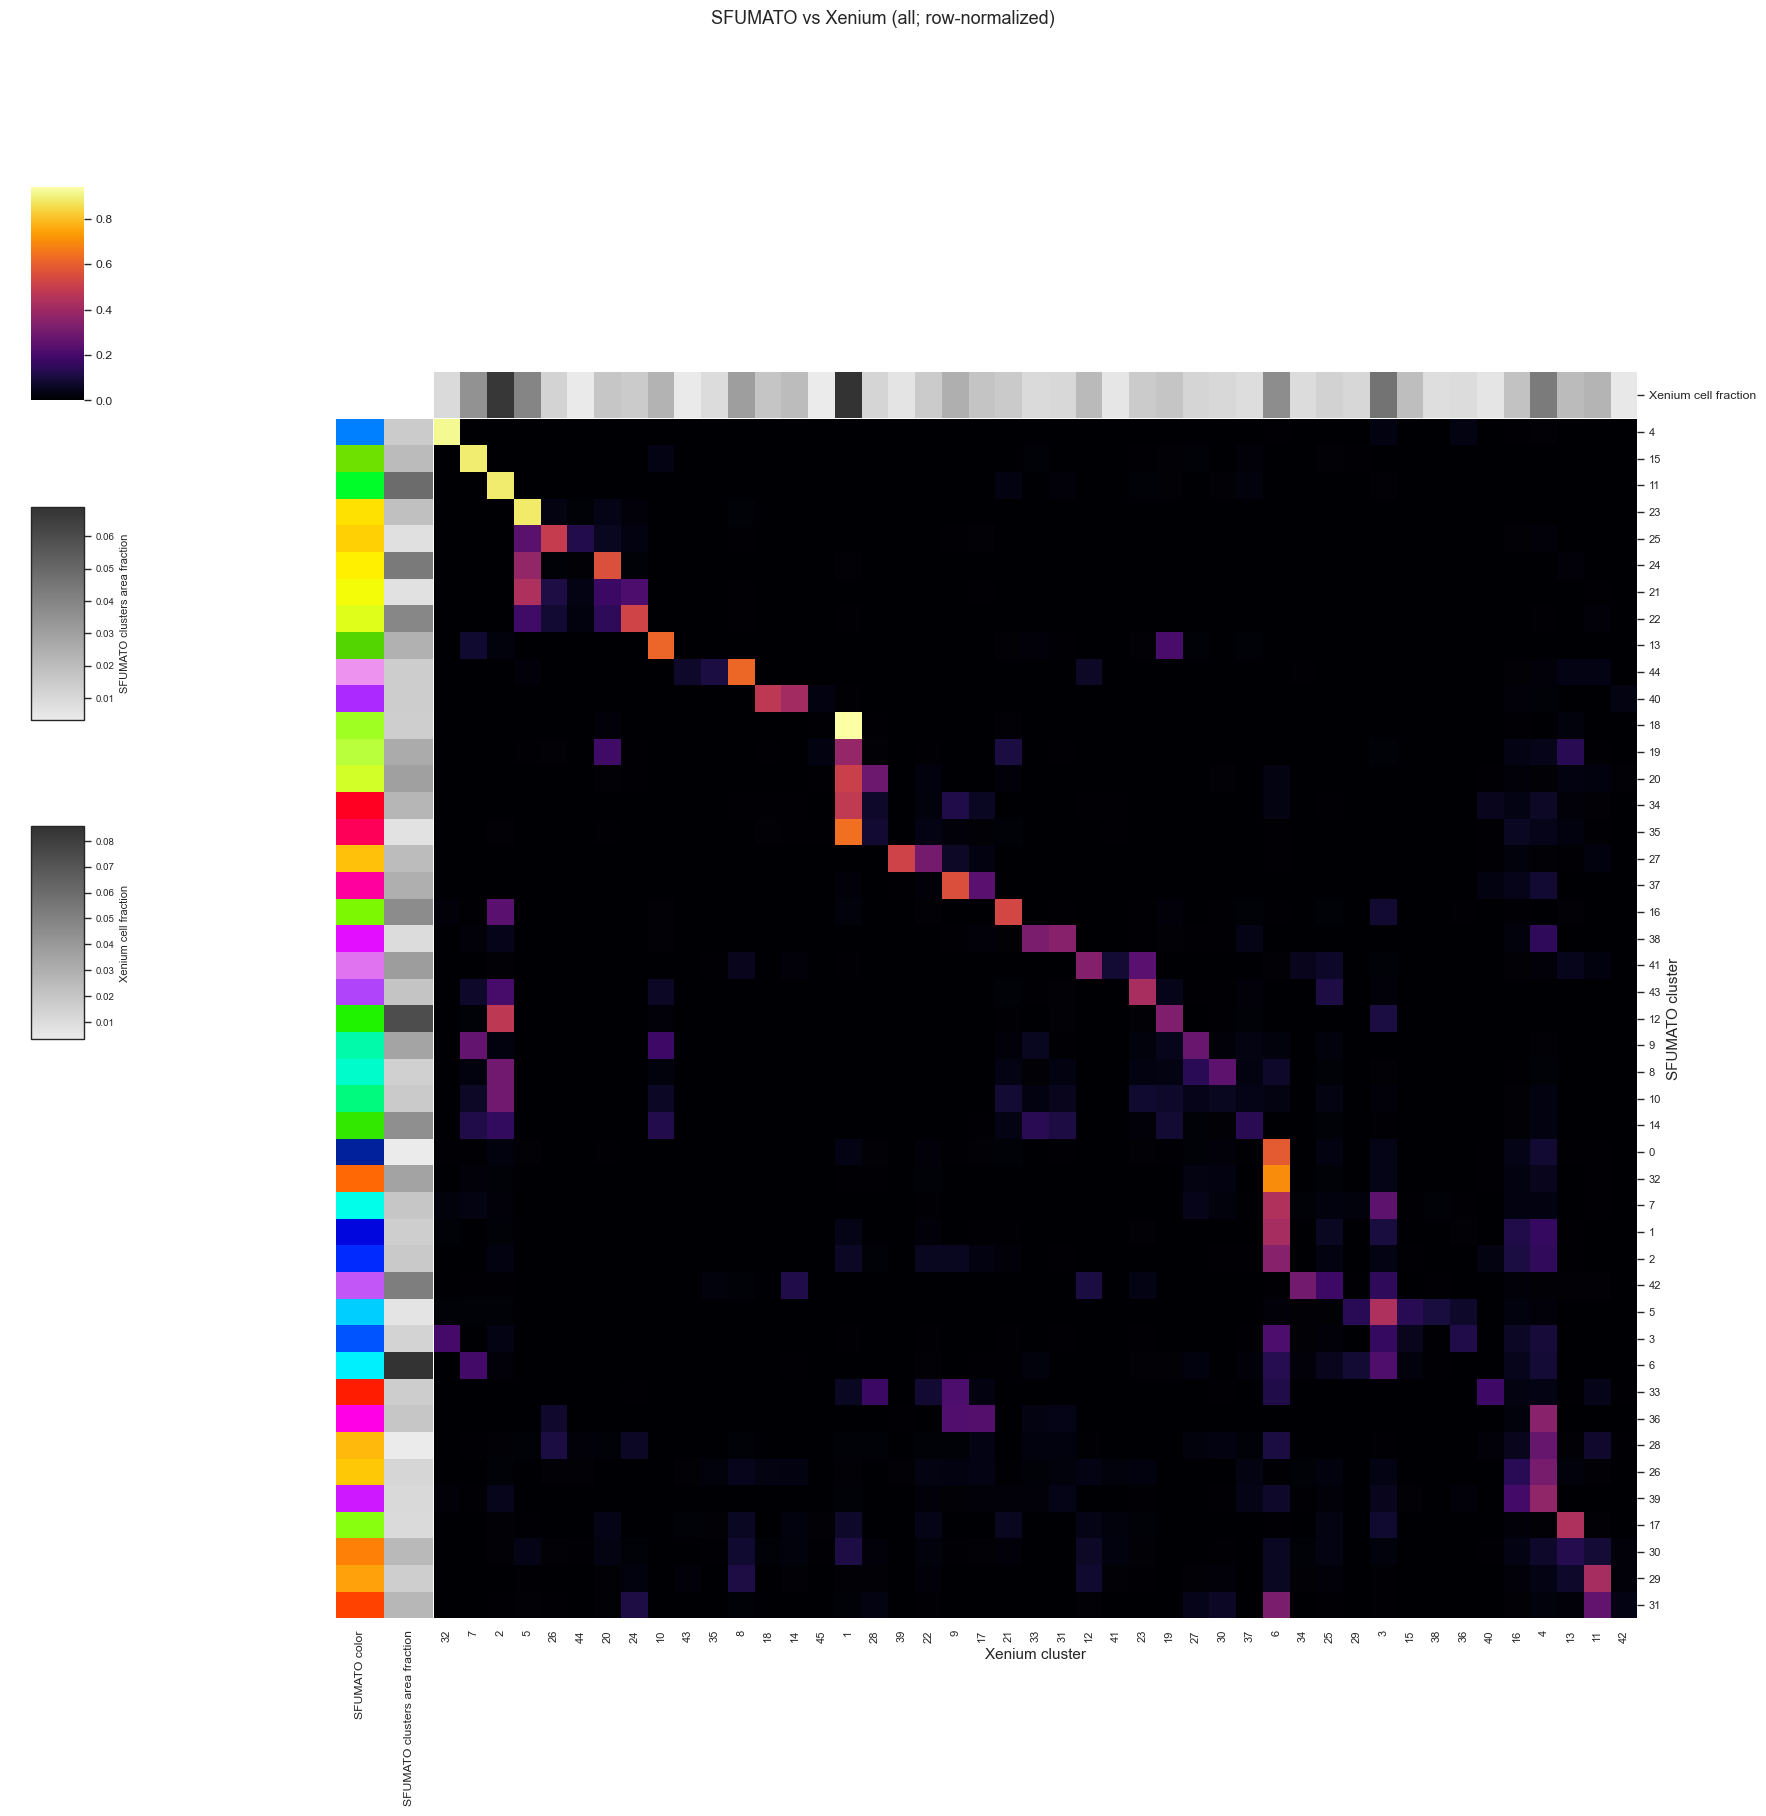

In [8]:
g_all = run_xenium_comparison(merged, label="all")


High-confidence threshold: p1 >= 0.8
High-confidence matched transcripts: 33,630,137 / 42,151,031
p1_ge_0_8: matrix shape = (45, 45); total overlap count = 32,493,165


xenium_cluster,1,10,11,12,13,14,15,16,17,18,19,2,20,21,22,23,24,25,26,27,28,29,3,30,31,32,33,34,35,36,37,38,39,4,40,41,42,43,44,45,5,6,7,8,9
sfumato_cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,3523,197,312,130,413,77,113,3804,766,133,310,1620,527,940,1348,527,265,2333,275,864,734,72,2968,998,406,355,279,240,10,156,294,25,57,8094,362,3,26,2,75,33,717,59906,458,126,696
1,3734,9,71,50,510,25,147,12329,527,13,15,832,0,359,1478,839,0,5558,0,15,247,20,10058,124,147,1171,15,127,0,946,70,5,58,16618,28,0,2,0,0,0,0,40793,27,2,358
10,961,24238,201,180,564,135,6,3337,1097,9,30910,125931,9,36475,1134,34169,9,11766,4,16641,225,190,4785,20943,22756,40,12421,422,17,20,15919,2,15,10608,184,16,1,1,4,2,24,10332,26046,31,898
11,1061,242,13,44,438,14,0,1704,1014,0,14051,2756267,0,65545,452,33051,0,2131,1,433,81,8,16896,23116,40134,901,323,390,5,35,56230,0,0,1779,3,0,0,0,0,0,0,536,770,96,547
12,26,8256,7,44,66,246,3,1292,736,0,391813,519120,2,6056,177,9713,0,2838,0,2842,8,226,125202,4550,10361,473,3744,238,46,0,14108,0,0,1925,57,0,0,0,0,0,0,1604,6830,17,251


Saved: sfumato_xenium_comparison_BIN7\sfumato_vs_xenium_p1_ge_0_8.pdf


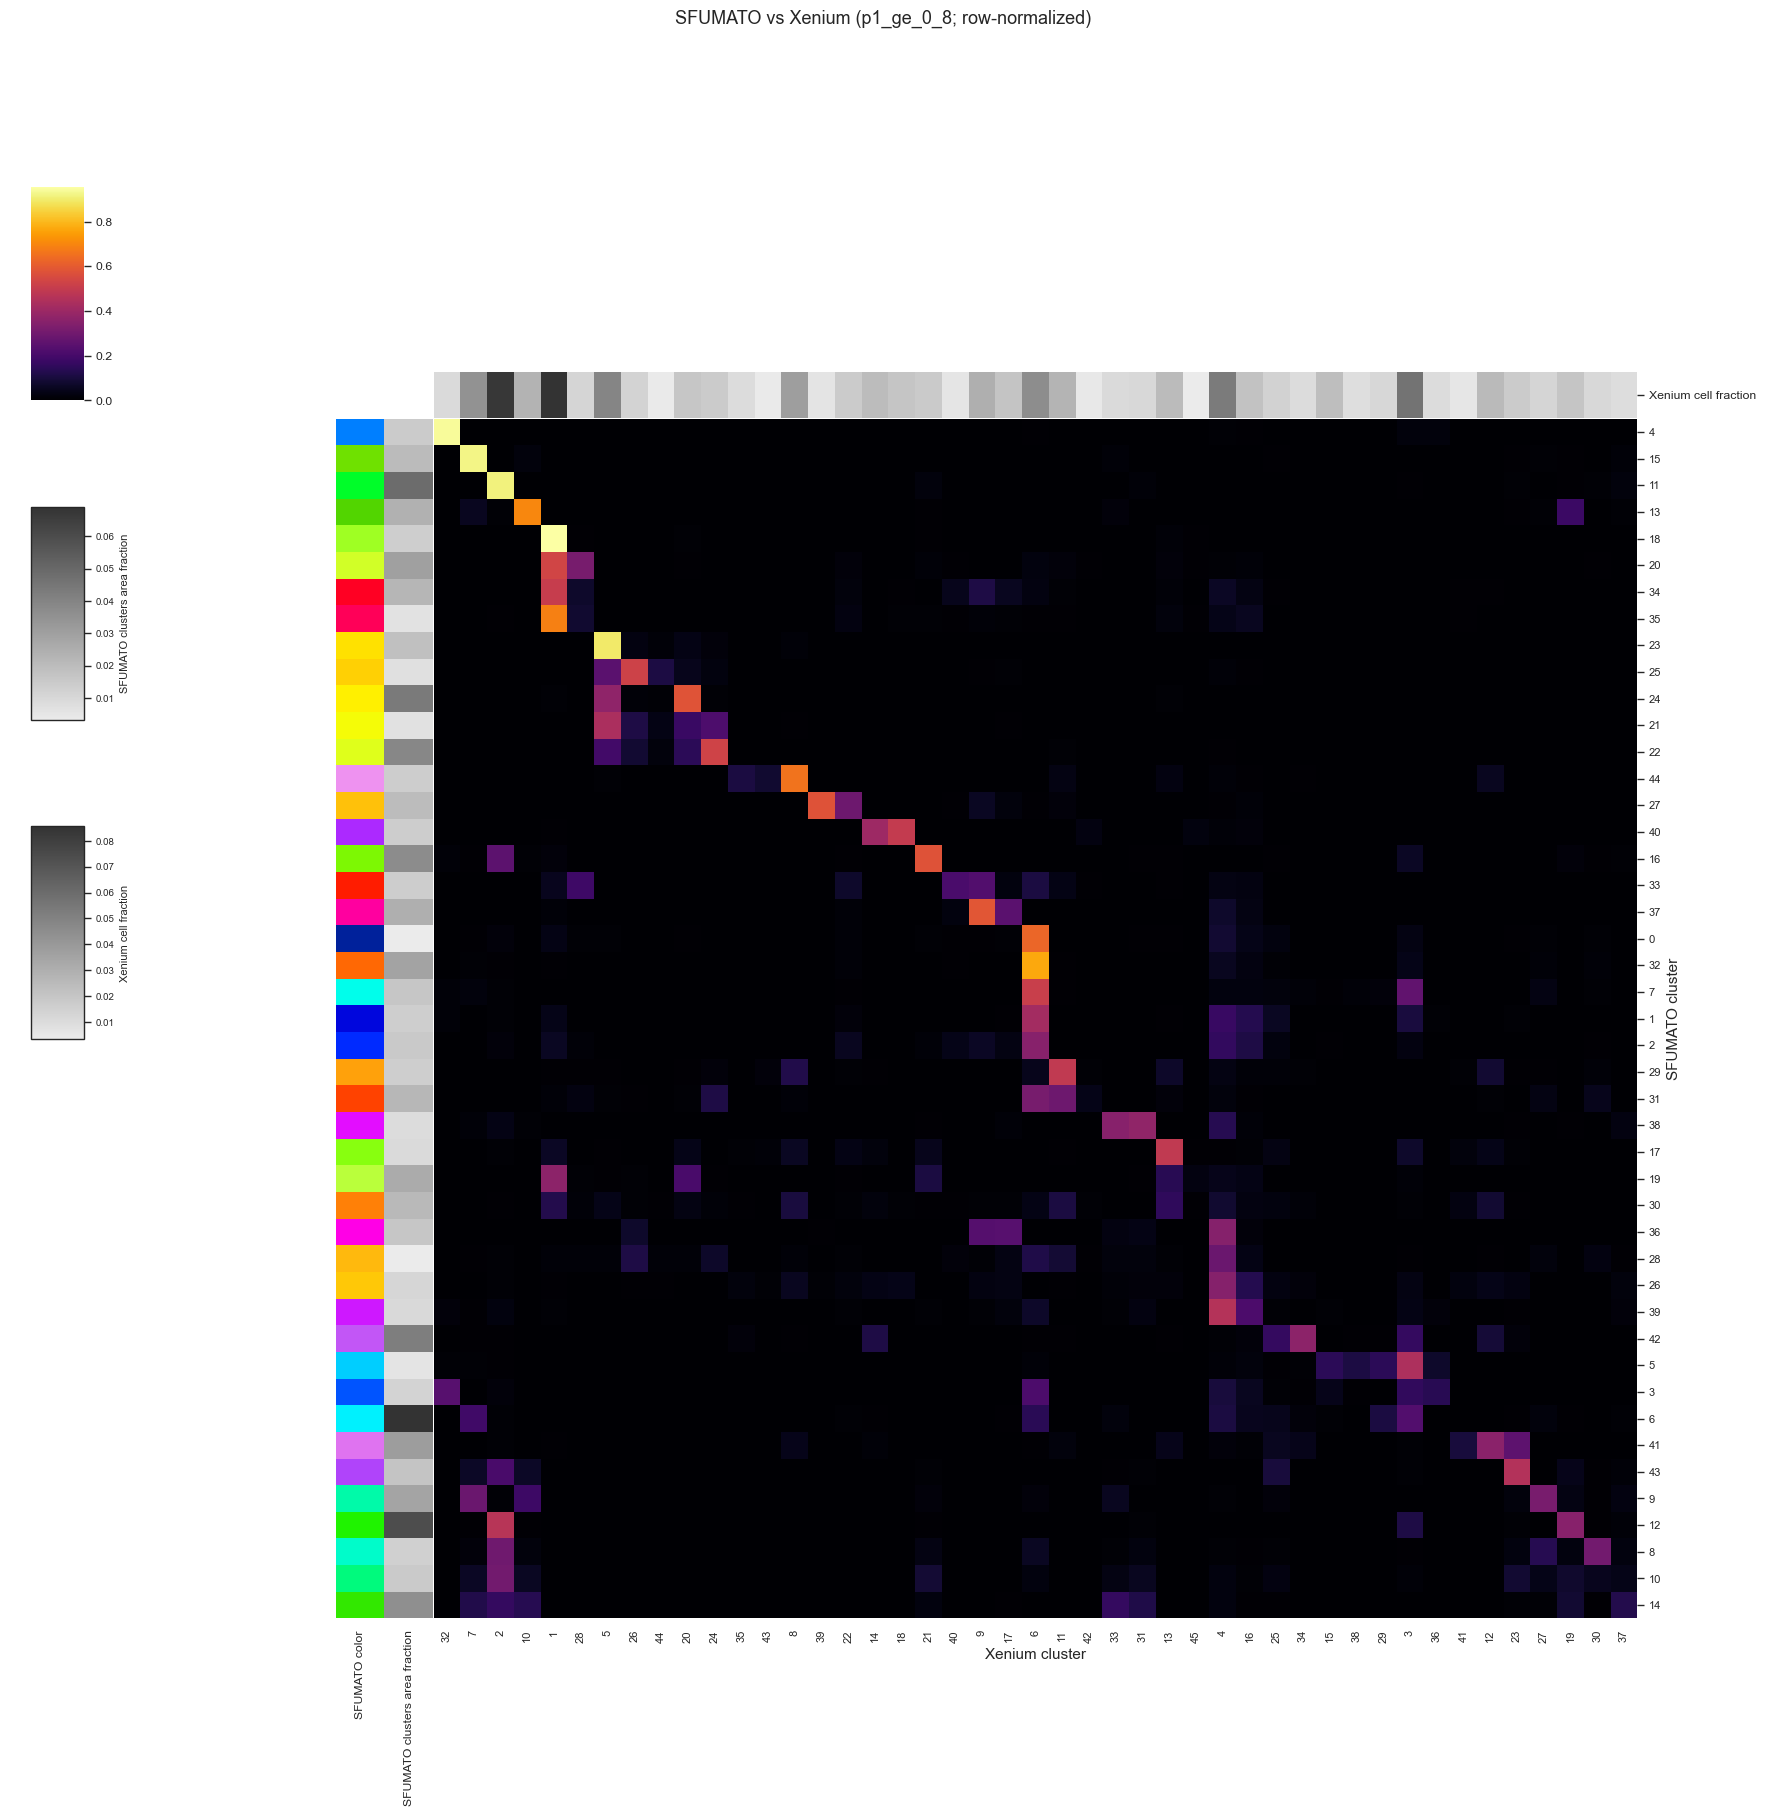

In [9]:
merged_high_conf = merged[merged["p1"] >= P1_THRESHOLD].copy()
print(f"High-confidence threshold: p1 >= {P1_THRESHOLD}")
print(f"High-confidence matched transcripts: {len(merged_high_conf):,} / {len(merged):,}")
g_high = run_xenium_comparison(merged_high_conf, label=f"p1_ge_{str(P1_THRESHOLD).replace('.', '_')}")
